<a href="https://colab.research.google.com/github/kxrrym03/Sleep-Doomscrolling-Habits/blob/main/Sleep_%26_Doomscrolling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving sleep_doomscrolling_habits.csv to sleep_doomscrolling_habits.csv


In [3]:
df = pd.read_csv('sleep_doomscrolling_habits.csv')
df.shape

(1000, 30)

In [4]:
df.head()

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,...,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
0,D30000,22,13.0,1.85,2,5.4,8.1,19.0,2,155.0,...,Unemployed,Germany,Tablet,Meditation/Journaling,Yes,Yes,Yes,No,Yes,Good
1,D30001,18,90.0,3.61,3,29.6,7.0,31.0,3,82.0,...,Student,India,Smartphone,Meditation/Journaling,No,Yes,Yes,No,Yes,Poor
2,D30002,37,51.0,5.15,3,15.5,7.1,24.0,2,49.0,...,Student,India,Laptop,Reading,No,Yes,No,Yes,Yes,Fair
3,D30003,27,53.0,3.74,0,51.4,8.4,35.0,0,42.0,...,NaN,United States,Smartphone,No Fixed Routine,No,Yes,Yes,No,No,Fair
4,D30004,17,67.0,6.09,2,32.2,7.2,19.0,1,76.0,...,Employed Part-time,United States,Smartphone,Watching Videos,No,No,No,No,No,Fair


In [5]:
df.tail()

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,...,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
995,D30995,26,85.0,3.56,4,25.4,7.6,34.0,1,169.0,...,Student,India,Tablet,Meditation/Journaling,No,Yes,Yes,Yes,Yes,Poor
996,D30996,23,3.0,1.10,1,10.7,7.5,31.0,1,34.0,...,Student,United States,Smartphone,Scrolling Social Media,No,Yes,No,No,No,Fair
997,D30997,15,28.0,4.38,1,30.6,9.2,20.0,0,100.0,...,Employed Full-time,United States,Smartphone,Scrolling Social Media,No,Yes,No,No,No,Good
998,D30998,22,23.0,1.84,0,27.9,6.9,41.0,2,45.0,...,Student,India,Tablet,Watching Videos,No,Yes,Yes,Yes,No,Fair
999,D30999,23,35.0,1.66,2,16.2,7.5,27.0,2,63.0,...,Employed Full-time,India,Tablet,Scrolling Social Media,No,Yes,Yes,No,Yes,Fair


In [6]:
df.columns

Index(['respondent_id', 'age', 'bedtime_screen_time_minutes',
       'total_daily_screen_time_hours', 'doomscroll_sessions_per_night',
       'avg_doomscroll_session_minutes', 'sleep_hours_per_night',
       'sleep_latency_minutes', 'number_of_night_wakeups',
       'caffeine_intake_mg_per_day', 'anxiety_score', 'stress_score',
       'sleep_quality_score', 'daytime_fatigue_score',
       'number_of_news_apps_used', 'phone_checks_per_night',
       'exercise_minutes_per_day', 'days_since_last_digital_detox',
       'weekly_sleep_debt_hours', 'gender', 'occupation_status',
       'country_region', 'primary_device_used_at_night',
       'bedtime_routine_type', 'uses_night_mode', 'keeps_phone_in_bedroom',
       'consumes_negative_news_content', 'uses_sleep_tracking_app',
       'doomscroller', 'sleep_quality_category'],
      dtype='object')

In [7]:
df.dtypes

,0
respondent_id,object
age,int64
bedtime_screen_time_minutes,float64
total_daily_screen_time_hours,float64
doomscroll_sessions_per_night,int64
avg_doomscroll_session_minutes,float64
sleep_hours_per_night,float64
sleep_latency_minutes,float64
number_of_night_wakeups,int64
caffeine_intake_mg_per_day,float64


In [8]:
df.isnull().sum()

,0
respondent_id,0
age,0
bedtime_screen_time_minutes,0
total_daily_screen_time_hours,0
doomscroll_sessions_per_night,0
avg_doomscroll_session_minutes,0
sleep_hours_per_night,0
sleep_latency_minutes,0
number_of_night_wakeups,0
caffeine_intake_mg_per_day,50


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Impute numerical columns with the median
numerical_cols_with_nulls = [
    'caffeine_intake_mg_per_day',
    'sleep_quality_score',
    'exercise_minutes_per_day'
]

for col in numerical_cols_with_nulls:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"Missing values in '{col}' imputed with median: {median_val}")

Missing values in 'caffeine_intake_mg_per_day' imputed with median: 102.0
Missing values in 'sleep_quality_score' imputed with median: 5.0
Missing values in 'exercise_minutes_per_day' imputed with median: 54.0


In [11]:
# Impute categorical columns with the mode
categorical_cols_with_nulls = [
    'occupation_status',
    'primary_device_used_at_night',
    'bedtime_routine_type'
]

for col in categorical_cols_with_nulls:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"Missing values in '{col}' imputed with mode: {mode_val}")

Missing values in 'occupation_status' imputed with mode: Employed Full-time
Missing values in 'primary_device_used_at_night' imputed with mode: Smartphone
Missing values in 'bedtime_routine_type' imputed with mode: Scrolling Social Media


In [12]:
# Verify that all null values have been handled
display(df.isnull().sum())

,0
respondent_id,0
age,0
bedtime_screen_time_minutes,0
total_daily_screen_time_hours,0
doomscroll_sessions_per_night,0
avg_doomscroll_session_minutes,0
sleep_hours_per_night,0
sleep_latency_minutes,0
number_of_night_wakeups,0
caffeine_intake_mg_per_day,0


## Data Visualization

### Distribution of Numerical Features

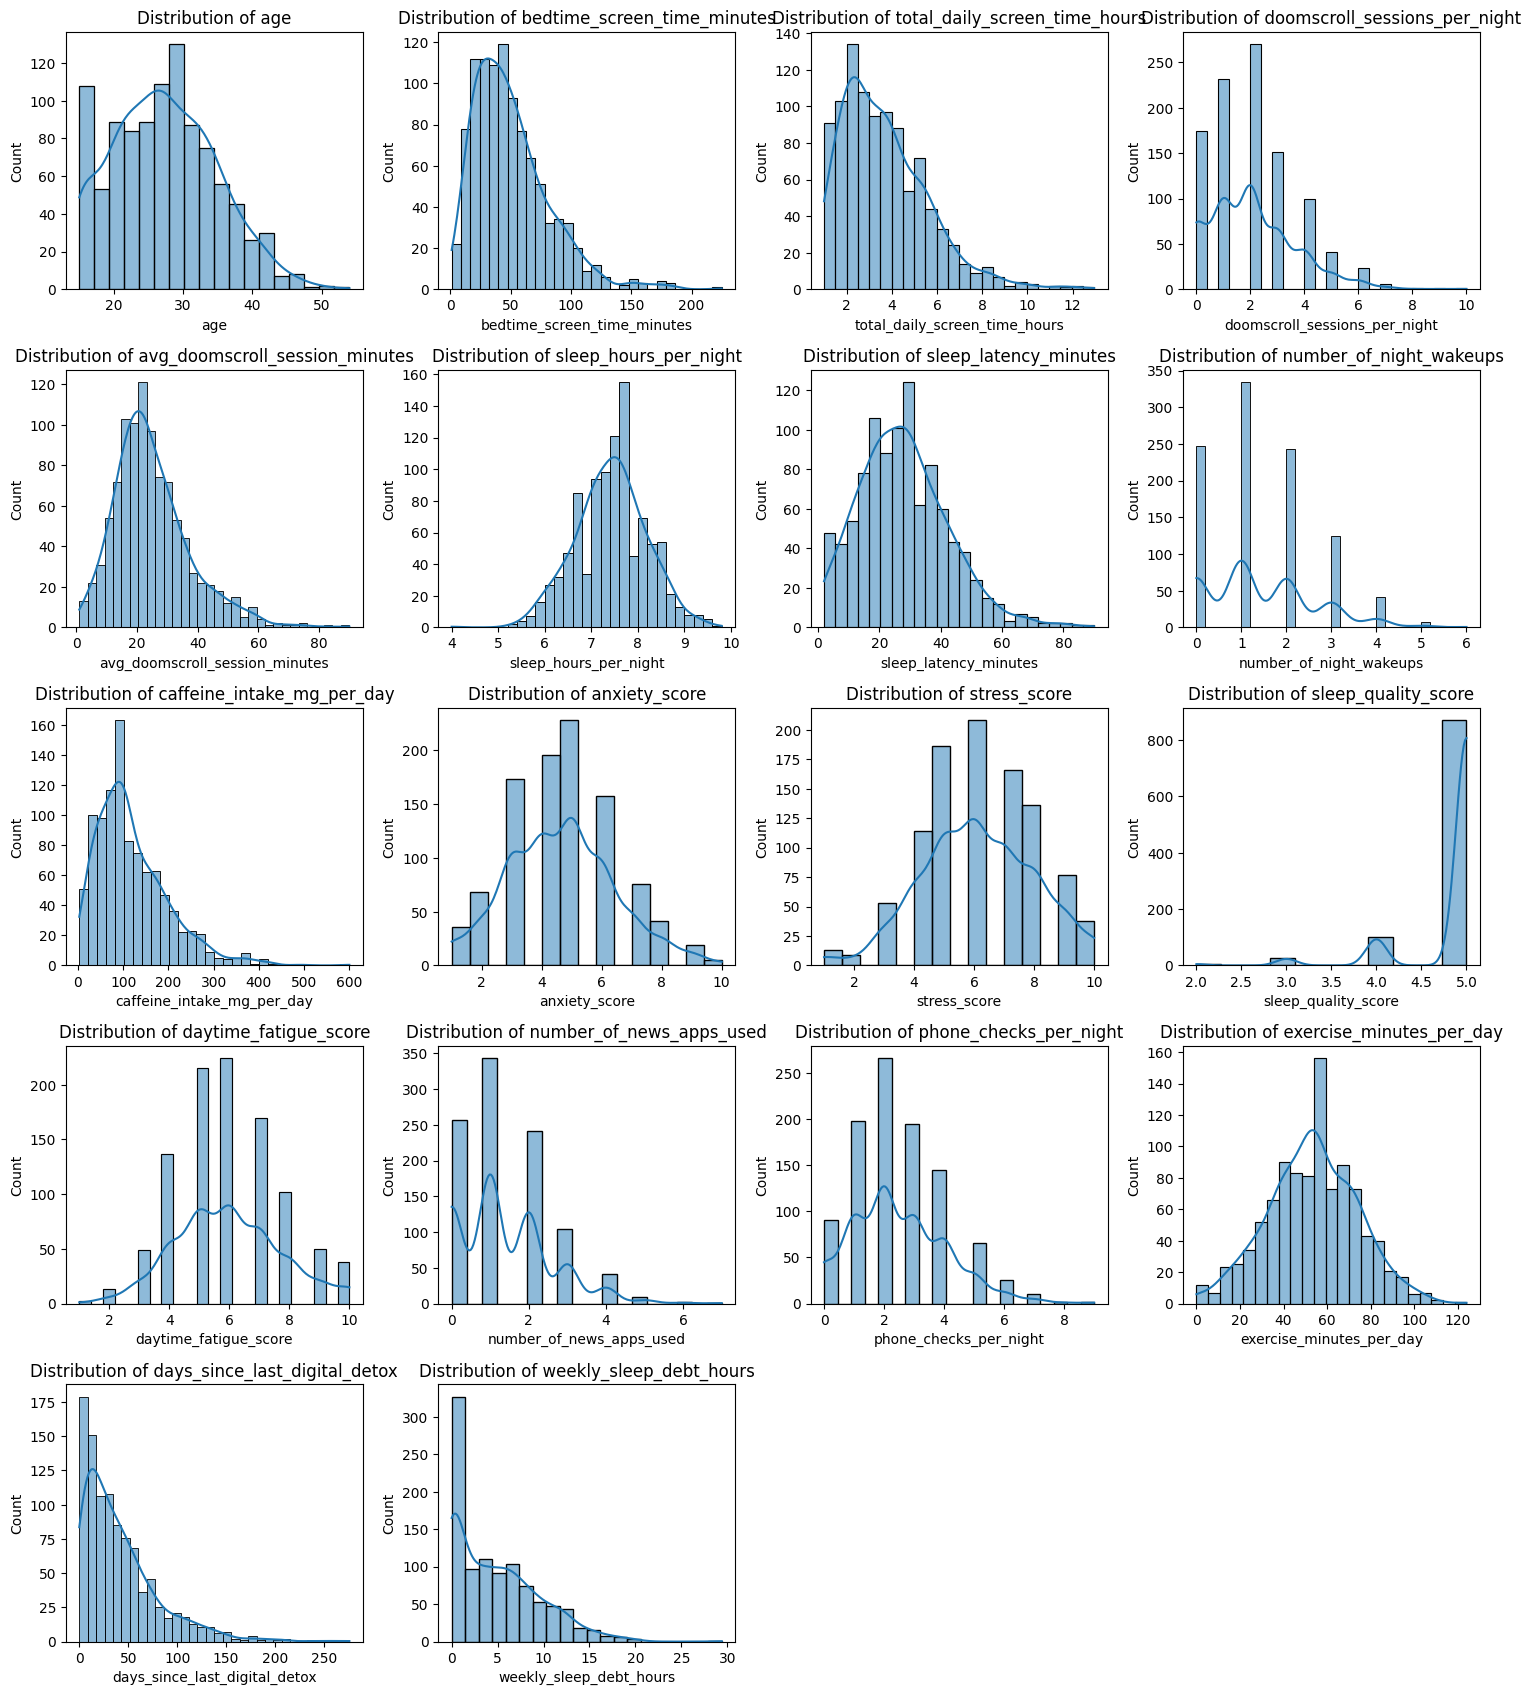

In [13]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 4, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

### Distribution of Categorical Features

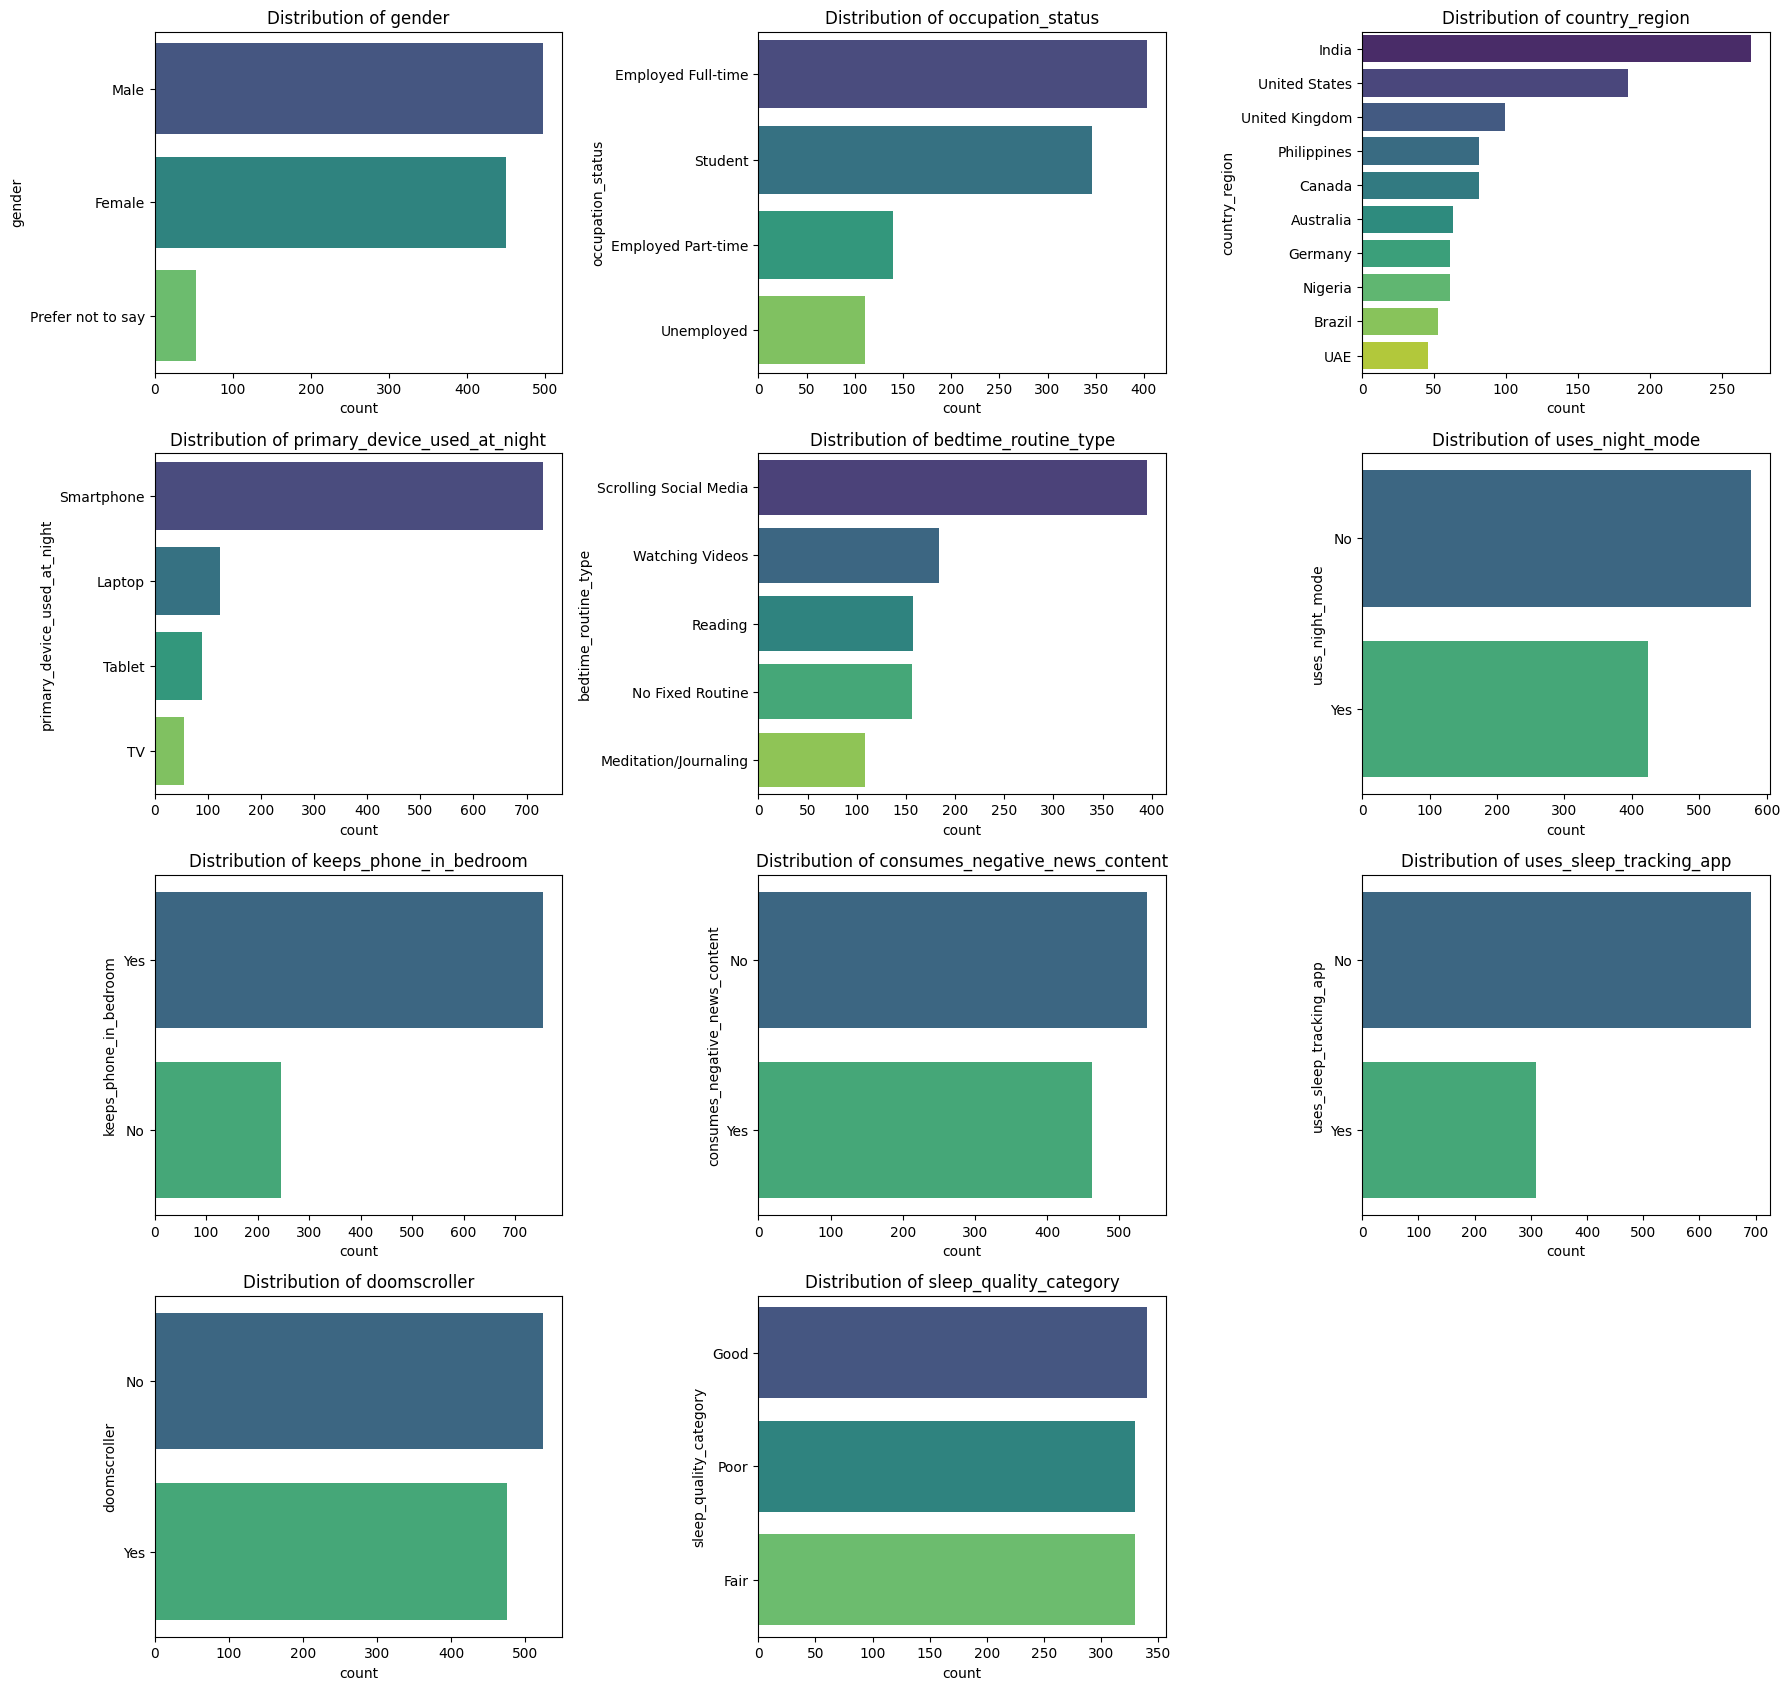

In [14]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

categorical_cols.remove('respondent_id')

plt.figure(figsize=(18, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(6, 3, i + 1)
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

### Relationship between Doomscrolling and Sleep Quality

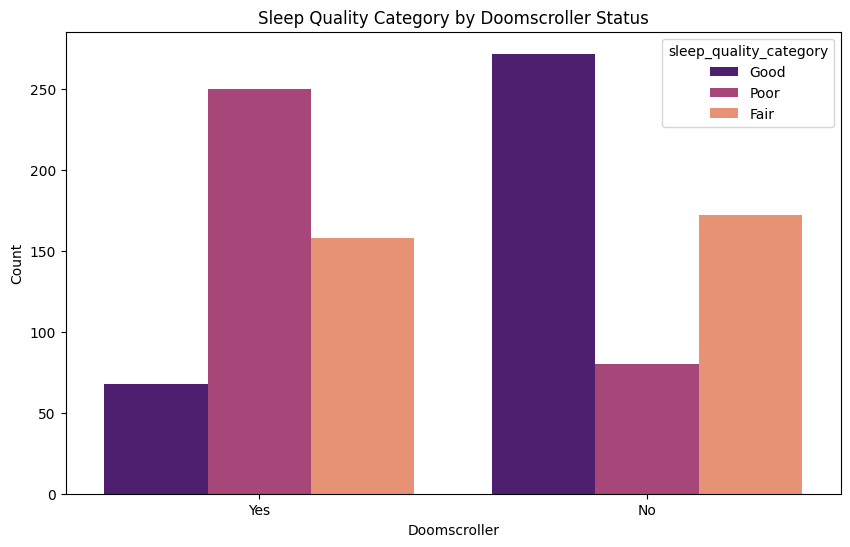

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='doomscroller', hue='sleep_quality_category', palette='magma')
plt.title('Sleep Quality Category by Doomscroller Status')
plt.xlabel('Doomscroller')
plt.ylabel('Count')
plt.show()

### Correlation between Bedtime Screen Time and Sleep Quality

In [16]:
correlation = df['bedtime_screen_time_minutes'].corr(df['sleep_quality_score'])
print(f"Correlation between bedtime screen time and sleep quality: {correlation:.2f}")

Correlation between bedtime screen time and sleep quality: -0.42


### Scatter Plot: Bedtime Screen Time vs. Sleep Quality

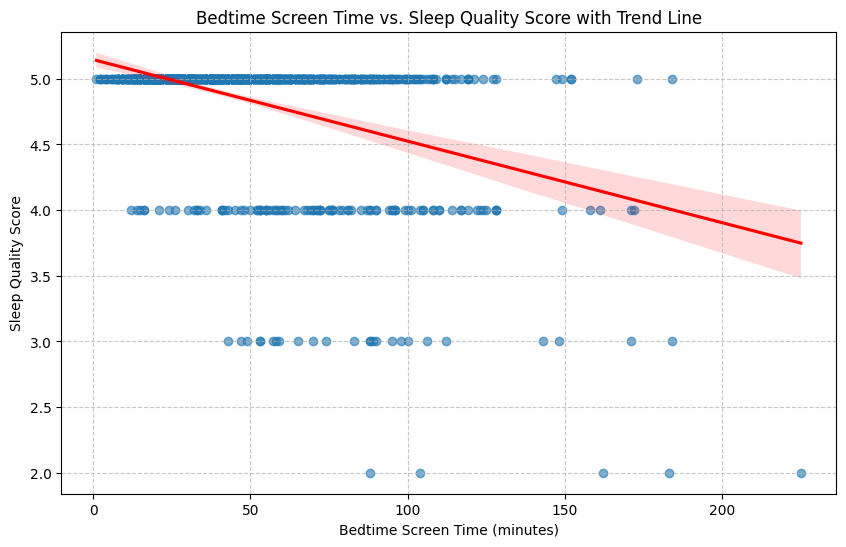

In [18]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='bedtime_screen_time_minutes', y='sleep_quality_score',
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Bedtime Screen Time vs. Sleep Quality Score with Trend Line')
plt.xlabel('Bedtime Screen Time (minutes)')
plt.ylabel('Sleep Quality Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Average Sleep Quality Score for Doomscrollers vs. Non-Doomscrollers

In [20]:
average_sleep_quality = df.groupby('doomscroller')['sleep_quality_score'].mean().reset_index()
print("Average Sleep Quality Score by Doomscroller Status:")
print(average_sleep_quality)

Average Sleep Quality Score by Doomscroller Status:
  doomscroller  sleep_quality_score
0           No             4.912214
1          Yes             4.750000


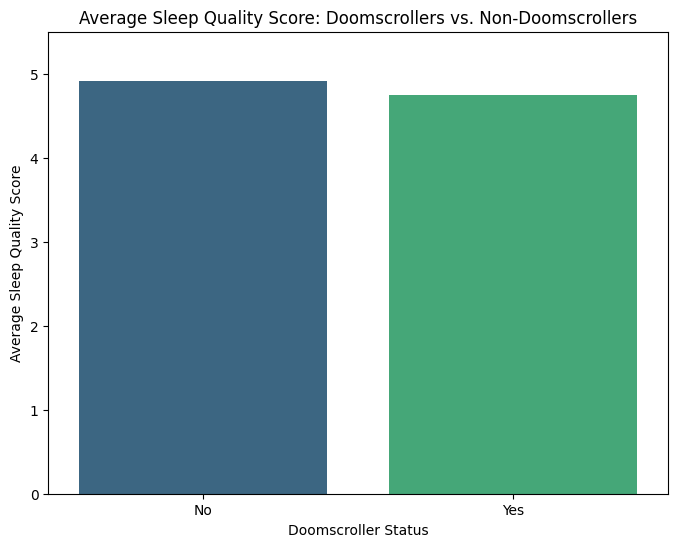

In [21]:
plt.figure(figsize=(8, 6))
sns.barplot(data=average_sleep_quality, x='doomscroller', y='sleep_quality_score', palette='viridis')
plt.title('Average Sleep Quality Score: Doomscrollers vs. Non-Doomscrollers')
plt.xlabel('Doomscroller Status')
plt.ylabel('Average Sleep Quality Score')
plt.ylim(0, df['sleep_quality_score'].max() * 1.1)
plt.show()